## Reading MoCap Data

In [22]:
import pandas as pd
import numpy as np

def quaternion_to_euler(x, y, z, w):
    """
    Convert quaternion (x,y,z,w) to Euler angles (roll, pitch, yaw) in degrees
    """
    # Roll (rotation around X-axis)
    sinr_cosp = 2 * (w * x + y * z)
    cosr_cosp = 1 - 2 * (x * x + y * y)
    roll = np.arctan2(sinr_cosp, cosr_cosp)
    
    # Pitch (rotation around Y-axis)
    sinp = 2 * (w * y - z * x)
    if abs(sinp) >= 1:
        pitch = np.copysign(np.pi / 2, sinp)  # Use 90 degrees if out of range
    else:
        pitch = np.arcsin(sinp)
    
    # Yaw (rotation around Z-axis)
    siny_cosp = 2 * (w * z + x * y)
    cosy_cosp = 1 - 2 * (y * y + z * z)
    yaw = np.arctan2(siny_cosp, cosy_cosp)
    
    # Convert from radians to degrees
    roll_deg = np.degrees(roll)
    pitch_deg = np.degrees(pitch)
    yaw_deg = np.degrees(yaw)
    
    return roll_deg, pitch_deg, yaw_deg

def parse_mocap_file(filename):
    """
    Parse the motion capture CSV file and extract marker positions and orientation
    """
    # Read the file
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # Find where the data starts (look for "Frame,Time" line)
    data_start = 0
    for i, line in enumerate(lines):
        if line.startswith("Frame,Time"):
            data_start = i
            break
    
    # Read just the data portion
    df = pd.read_csv(filename, skiprows=data_start)
    
    # The columns are a bit messy due to duplicate names, so we'll rename them
    # Based on the file structure:
    # Columns 0-1: Frame, Time
    # Columns 2-5: Quaternion (X,Y,Z,W)
    # Columns 6-8: Rigid body position (X,Y,Z)
    # Columns 22-24: Marker1 position (X,Y,Z)
    # Columns 25-27: Marker2 position (X,Y,Z)
    # Columns 28-30: Marker3 position (X,Y,Z)
    
    # Create a cleaner dataframe
    clean_data = pd.DataFrame()
    
    # Basic info
    clean_data['Frame'] = df.iloc[:, 0]
    clean_data['Time'] = df.iloc[:, 1]
    
    # Quaternion data
    clean_data['Quat_X'] = df.iloc[:, 2]
    clean_data['Quat_Y'] = df.iloc[:, 3]
    clean_data['Quat_Z'] = df.iloc[:, 4]
    clean_data['Quat_W'] = df.iloc[:, 5]
    
    # Marker positions (in meters)
    clean_data['Marker1_X'] = df.iloc[:, 22]
    clean_data['Marker1_Y'] = df.iloc[:, 23]
    clean_data['Marker1_Z'] = df.iloc[:, 24]
    
    clean_data['Marker2_X'] = df.iloc[:, 25]
    clean_data['Marker2_Y'] = df.iloc[:, 26]
    clean_data['Marker2_Z'] = df.iloc[:, 27]
    
    clean_data['Marker3_X'] = df.iloc[:, 28]
    clean_data['Marker3_Y'] = df.iloc[:, 29]
    clean_data['Marker3_Z'] = df.iloc[:, 30]
    
    # Calculate Euler angles for each frame
    euler_angles = []
    for _, row in clean_data.iterrows():
        roll, pitch, yaw = quaternion_to_euler(
            row['Quat_X'], row['Quat_Y'], row['Quat_Z'], row['Quat_W']
        )
        euler_angles.append((roll, pitch, yaw))
    
    # Add Euler angles to dataframe
    clean_data['Roll_deg'] = [e[0] for e in euler_angles]
    clean_data['Pitch_deg'] = [e[1] for e in euler_angles]
    clean_data['Yaw_deg'] = [e[2] for e in euler_angles]
    
    return clean_data

# Example usage:
if __name__ == "__main__":
    # Load your file
    data = parse_mocap_file('run13.csv')
    
    # Display first few rows
    print("First 5 frames of data:")
    print(data[['Frame', 'Time', 'Marker1_X', 'Marker1_Y', 'Marker1_Z', 
                'Roll_deg', 'Pitch_deg', 'Yaw_deg']].head())
    
    # Get data for a specific frame
    frame_100 = data[data['Frame'] == 100].iloc[0]
    print(f"\nFrame 100 (at time {frame_100['Time']:.3f} seconds):")
    print(f"Marker 1 position: X={frame_100['Marker1_X']:.4f}, Y={frame_100['Marker1_Y']:.4f}, Z={frame_100['Marker1_Z']:.4f} meters")
    print(f"Marker 2 position: X={frame_100['Marker2_X']:.4f}, Y={frame_100['Marker2_Y']:.4f}, Z={frame_100['Marker2_Z']:.4f} meters")
    print(f"Marker 3 position: X={frame_100['Marker3_X']:.4f}, Y={frame_100['Marker3_Y']:.4f}, Z={frame_100['Marker3_Z']:.4f} meters")
    print(f"Orientation: Roll={frame_100['Roll_deg']:.1f}°, Pitch={frame_100['Pitch_deg']:.1f}°, Yaw={frame_100['Yaw_deg']:.1f}°")
    
    # Save cleaned data to a new CSV
    data.to_csv('cleaned_mocap_data.csv', index=False)
    print("\nCleaned data saved to 'cleaned_mocap_data.csv'")

First 5 frames of data:
   Frame  Time  Marker1_X  Marker1_Y  Marker1_Z    Roll_deg  Pitch_deg  \
0      0  0.00  -0.124994   0.147689  -0.434487 -179.378029 -69.060314   
1      1  0.01  -0.125057   0.147625  -0.434370 -179.340952 -69.098482   
2      2  0.02  -0.124978   0.147549  -0.434528 -179.364561 -69.082037   
3      3  0.03  -0.124959   0.147491  -0.434472 -179.274952 -69.073569   
4      4  0.04  -0.124944   0.147554  -0.434455 -179.293513 -69.089495   

      Yaw_deg  
0 -178.305625  
1 -178.669106  
2 -178.225873  
3 -178.089876  
4 -178.138794  

Frame 100 (at time 1.000 seconds):
Marker 1 position: X=-0.1250, Y=0.1478, Z=-0.4344 meters
Marker 2 position: X=0.8838, Y=-0.0846, Z=0.1481 meters
Marker 3 position: X=-0.5660, Y=-0.1144, Z=0.1490 meters
Orientation: Roll=-179.0°, Pitch=-69.1°, Yaw=-178.5°

Cleaned data saved to 'cleaned_mocap_data.csv'


Generating 4-point clusters in 2D...


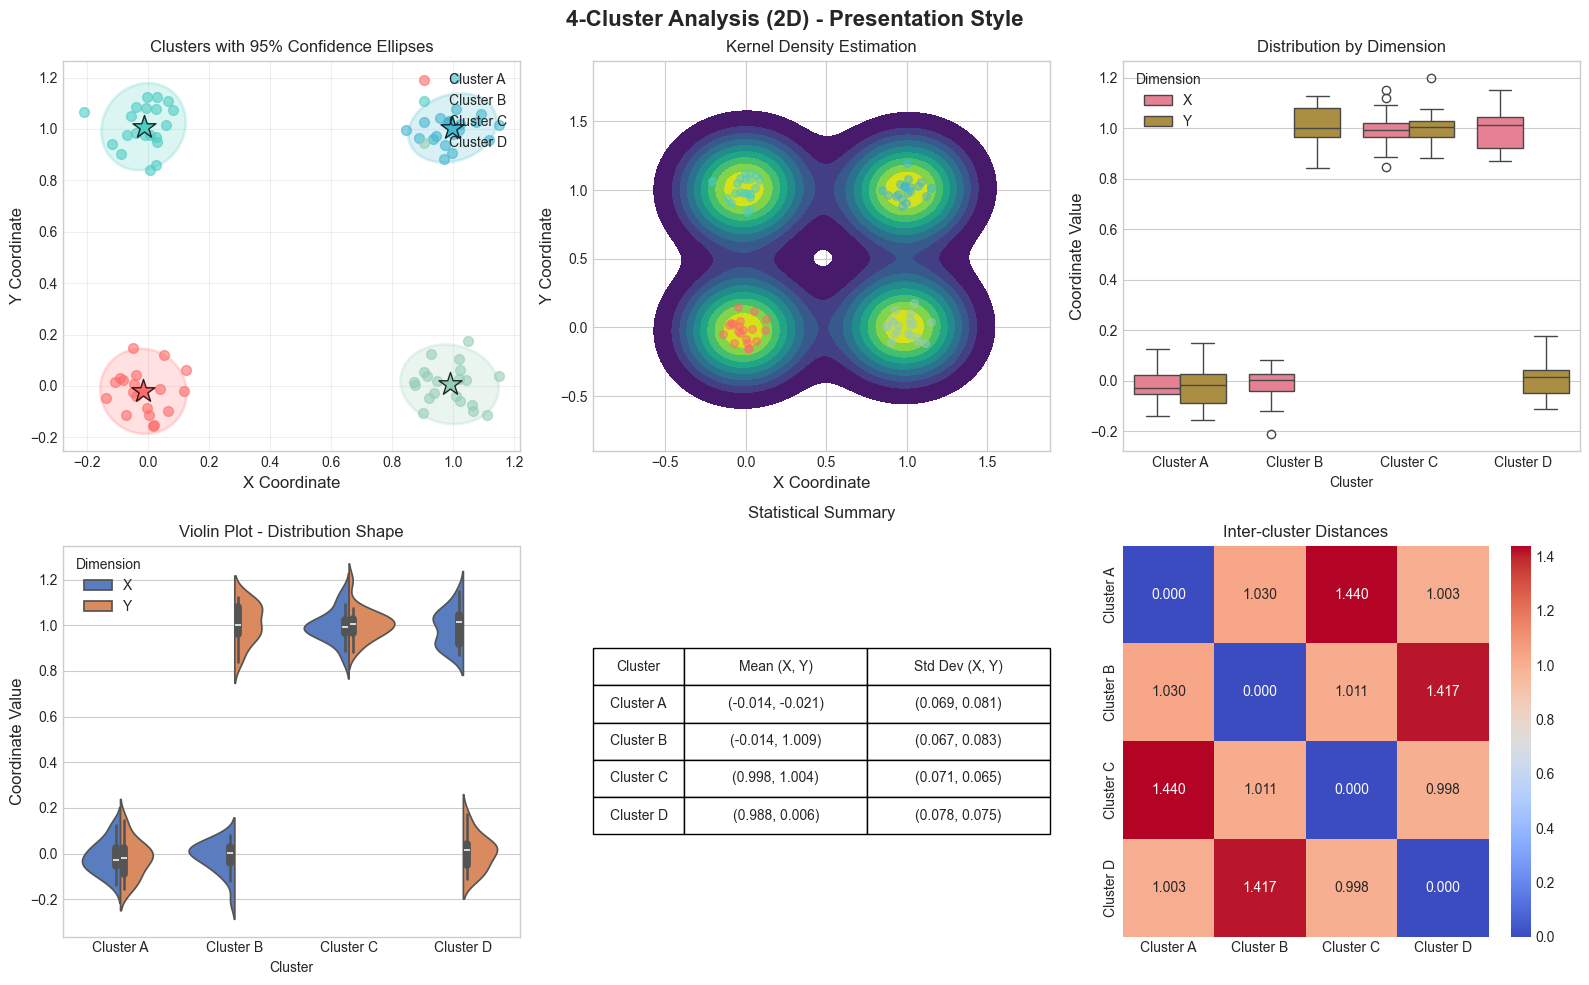

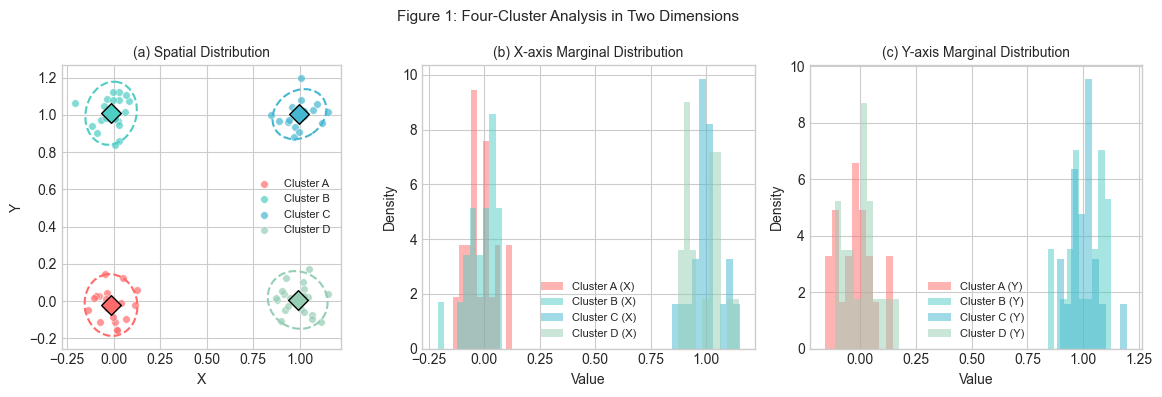


Generating 8-point clusters in 3D...


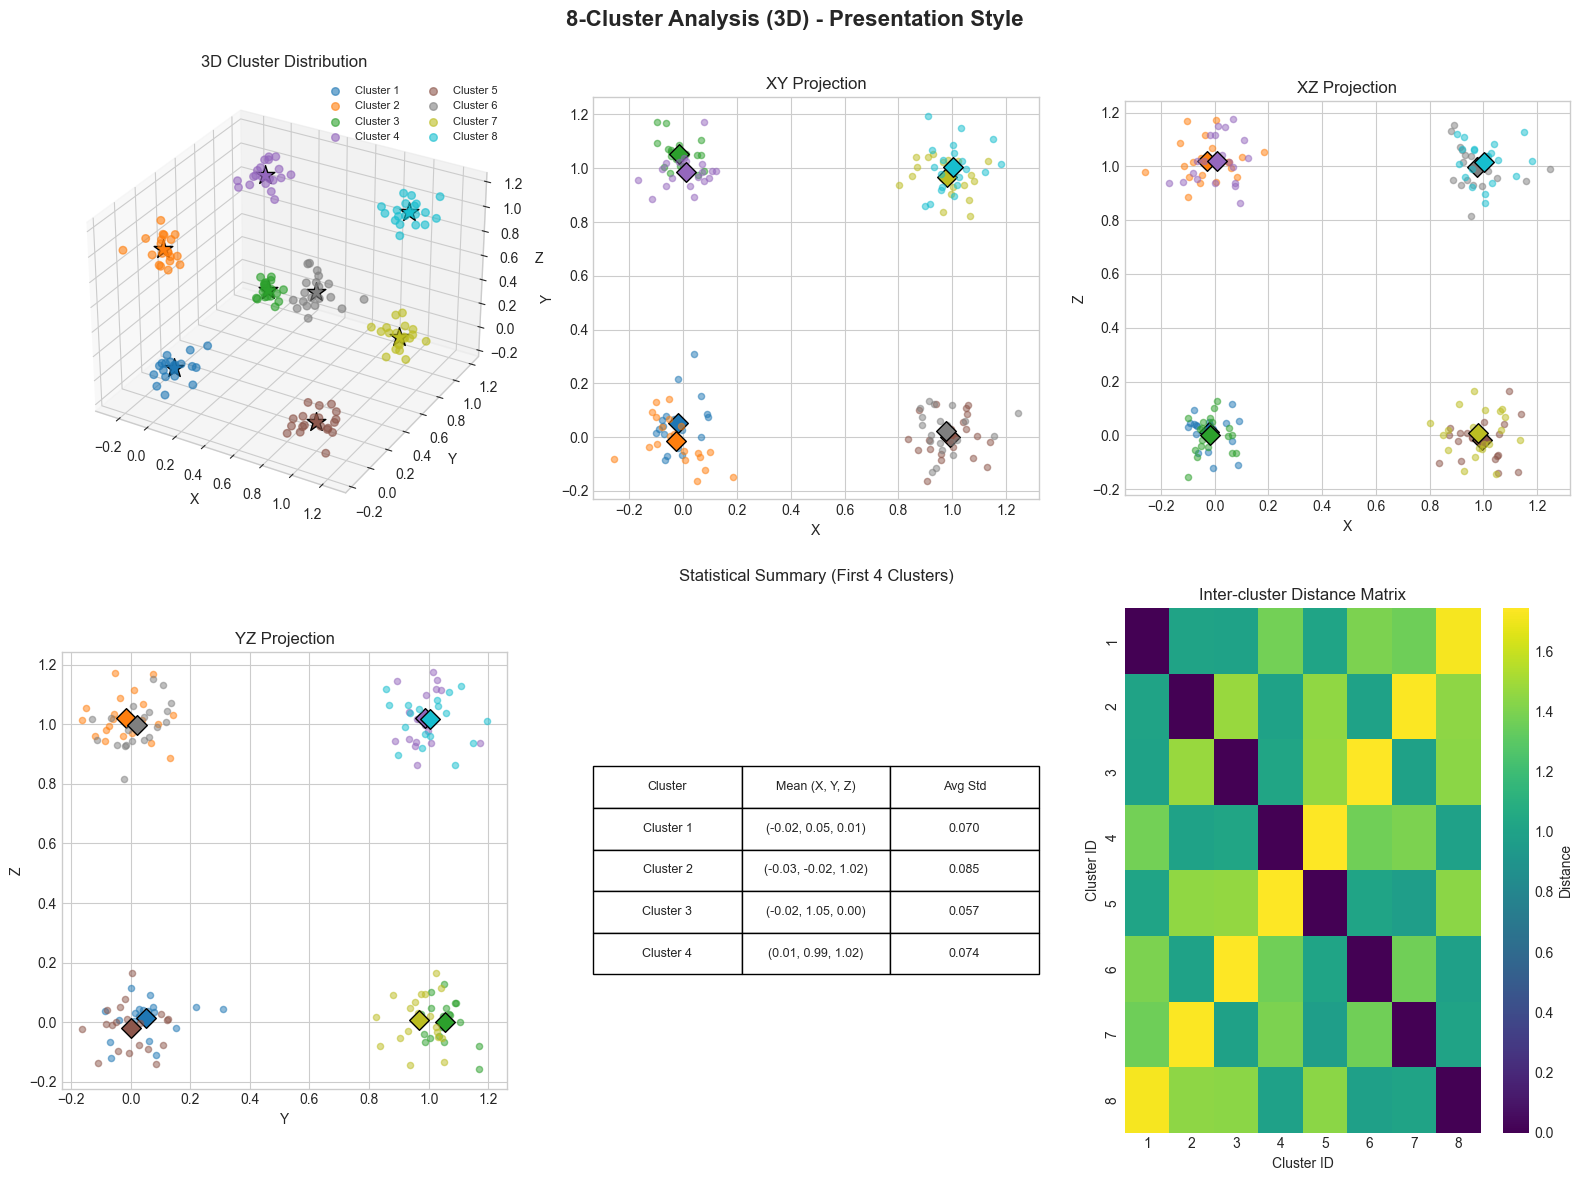

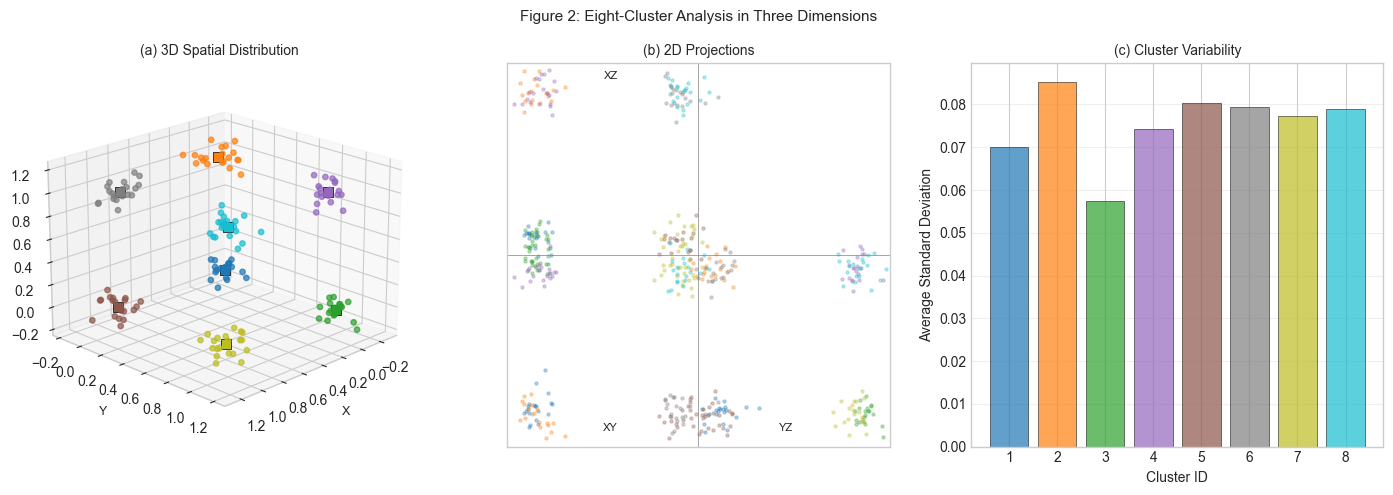


STATISTICAL SUMMARY

2D Clusters (4 points):
------------------------------

Cluster A:
  Mean: (-0.0141, -0.0209)
  Std:  (0.0690, 0.0809)
  Covariance matrix:
    [0.005017, -0.000277]
    [-0.000277, 0.006885]

Cluster B:
  Mean: (-0.0136, 1.0090)
  Std:  (0.0674, 0.0826)
  Covariance matrix:
    [0.004782, 0.000628]
    [0.000628, 0.007177]

Cluster C:
  Mean: (0.9977, 1.0039)
  Std:  (0.0705, 0.0655)
  Covariance matrix:
    [0.005232, 0.000926]
    [0.000926, 0.004511]

Cluster D:
  Mean: (0.9884, 0.0064)
  Std:  (0.0783, 0.0755)
  Covariance matrix:
    [0.006459, -0.000548]
    [-0.000548, 0.006000]


3D Clusters (8 points):
------------------------------

Cluster 1:
  Mean: (-0.0195, 0.0513, 0.0128)
  Std:  (0.0589, 0.0920, 0.0596)

Cluster 2:
  Mean: (-0.0266, -0.0154, 1.0209)
  Std:  (0.0971, 0.0862, 0.0728)

Cluster 3:
  Mean: (-0.0162, 1.0535, 0.0017)
  Std:  (0.0533, 0.0523, 0.0665)

Cluster 4:
  Mean: (0.0099, 0.9864, 1.0206)
  Std:  (0.0773, 0.0593, 0.0862)

Figures sa

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from scipy import stats
import pandas as pd
from matplotlib.patches import Ellipse
import matplotlib.patches as mpatches

# Set style for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Set random seed for reproducibility
np.random.seed(42)

def generate_cluster_data(center, n_points=20, std=0.05):
    """Generate noisy points around a center."""
    noise = np.random.randn(n_points, len(center)) * std
    return center + noise

def calculate_statistics(points):
    """Calculate mean, std, and covariance for a set of points."""
    mean = np.mean(points, axis=0)
    std = np.std(points, axis=0)
    cov = np.cov(points.T)
    return mean, std, cov

def plot_confidence_ellipse(ax, mean, cov, n_std=2.0, **kwargs):
    """Plot confidence ellipse for 2D data."""
    eigenvalues, eigenvectors = np.linalg.eig(cov)
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    ellipse = Ellipse(mean, width, height, angle=angle, **kwargs)
    ax.add_patch(ellipse)

# ============== PART 1: 4 POINTS (2D) ==============
print("Generating 4-point clusters in 2D...")

# Define 4 corner points
centers_2d = np.array([[0, 0], [0, 1], [1, 1], [1, 0]])
colors_2d = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
labels_2d = ['Cluster A', 'Cluster B', 'Cluster C', 'Cluster D']

# Generate data for each cluster
clusters_2d = []
stats_2d = []
for center in centers_2d:
    cluster = generate_cluster_data(center, n_points=20, std=0.08)
    clusters_2d.append(cluster)
    mean, std, cov = calculate_statistics(cluster)
    stats_2d.append({'mean': mean, 'std': std, 'cov': cov})

# Create comprehensive 2D visualization
fig1 = plt.figure(figsize=(16, 10))
fig1.suptitle('4-Cluster Analysis (2D) - Presentation Style', fontsize=16, fontweight='bold')

# Subplot 1: Scatter plot with confidence ellipses
ax1 = plt.subplot(2, 3, 1)
for i, (cluster, color, label) in enumerate(zip(clusters_2d, colors_2d, labels_2d)):
    ax1.scatter(cluster[:, 0], cluster[:, 1], c=color, label=label, alpha=0.6, s=50)
    ax1.scatter(stats_2d[i]['mean'][0], stats_2d[i]['mean'][1], 
                c=color, marker='*', s=300, edgecolor='black', linewidth=1)
    plot_confidence_ellipse(ax1, stats_2d[i]['mean'], stats_2d[i]['cov'], 
                          facecolor=color, alpha=0.2, edgecolor=color, linewidth=2)
ax1.set_xlabel('X Coordinate', fontsize=12)
ax1.set_ylabel('Y Coordinate', fontsize=12)
ax1.set_title('Clusters with 95% Confidence Ellipses', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Subplot 2: Density plot
ax2 = plt.subplot(2, 3, 2)
all_points = np.vstack(clusters_2d)
sns.kdeplot(data=pd.DataFrame(all_points, columns=['X', 'Y']), 
            x='X', y='Y', fill=True, cmap='viridis', ax=ax2)
for i, cluster in enumerate(clusters_2d):
    ax2.scatter(cluster[:, 0], cluster[:, 1], c=colors_2d[i], alpha=0.5, s=30)
ax2.set_xlabel('X Coordinate', fontsize=12)
ax2.set_ylabel('Y Coordinate', fontsize=12)
ax2.set_title('Kernel Density Estimation', fontsize=12)

# Subplot 3: Box plots for distributions
ax3 = plt.subplot(2, 3, 3)
data_for_box = []
for i, cluster in enumerate(clusters_2d):
    for point in cluster:
        data_for_box.append({'Cluster': labels_2d[i], 'X': point[0], 'Y': point[1]})
df_box = pd.DataFrame(data_for_box)
df_melted = df_box.melt(id_vars=['Cluster'], value_vars=['X', 'Y'], 
                        var_name='Dimension', value_name='Value')
sns.boxplot(data=df_melted, x='Cluster', y='Value', hue='Dimension', ax=ax3)
ax3.set_title('Distribution by Dimension', fontsize=12)
ax3.set_ylabel('Coordinate Value', fontsize=12)

# Subplot 4: Violin plot
ax4 = plt.subplot(2, 3, 4)
sns.violinplot(data=df_melted, x='Cluster', y='Value', hue='Dimension', 
               split=True, ax=ax4, palette='muted')
ax4.set_title('Violin Plot - Distribution Shape', fontsize=12)
ax4.set_ylabel('Coordinate Value', fontsize=12)

# Subplot 5: Statistics table
ax5 = plt.subplot(2, 3, 5)
ax5.axis('tight')
ax5.axis('off')
table_data = []
for i, label in enumerate(labels_2d):
    table_data.append([
        label,
        f"({stats_2d[i]['mean'][0]:.3f}, {stats_2d[i]['mean'][1]:.3f})",
        f"({stats_2d[i]['std'][0]:.3f}, {stats_2d[i]['std'][1]:.3f})"
    ])
table = ax5.table(cellText=table_data,
                  colLabels=['Cluster', 'Mean (X, Y)', 'Std Dev (X, Y)'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.2, 0.4, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
ax5.set_title('Statistical Summary', fontsize=12, pad=20)

# Subplot 6: Heatmap of distances between cluster centers
ax6 = plt.subplot(2, 3, 6)
dist_matrix = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        dist_matrix[i, j] = np.linalg.norm(stats_2d[i]['mean'] - stats_2d[j]['mean'])
sns.heatmap(dist_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            xticklabels=labels_2d, yticklabels=labels_2d, ax=ax6)
ax6.set_title('Inter-cluster Distances', fontsize=12)

plt.tight_layout()
plt.show()

# Journal-style figure for 2D
fig2 = plt.figure(figsize=(12, 4))
fig2.suptitle('Figure 1: Four-Cluster Analysis in Two Dimensions', fontsize=11)

# Panel A: Main scatter plot
ax2_1 = plt.subplot(1, 3, 1)
for i, (cluster, color, label) in enumerate(zip(clusters_2d, colors_2d, labels_2d)):
    ax2_1.scatter(cluster[:, 0], cluster[:, 1], c=color, label=label, 
                  alpha=0.7, s=30, edgecolors='white', linewidth=0.5)
    ax2_1.scatter(stats_2d[i]['mean'][0], stats_2d[i]['mean'][1], 
                  c=color, marker='D', s=100, edgecolor='black', linewidth=1)
    plot_confidence_ellipse(ax2_1, stats_2d[i]['mean'], stats_2d[i]['cov'], 
                          facecolor='none', edgecolor=color, linewidth=1.5, linestyle='--')
ax2_1.set_xlabel('X', fontsize=10)
ax2_1.set_ylabel('Y', fontsize=10)
ax2_1.set_title('(a) Spatial Distribution', fontsize=10)
ax2_1.legend(fontsize=8, framealpha=0.9)
ax2_1.set_aspect('equal')

# Panel B: Marginal distributions
ax2_2 = plt.subplot(1, 3, 2)
for i, (cluster, color) in enumerate(zip(clusters_2d, colors_2d)):
    ax2_2.hist(cluster[:, 0], bins=10, alpha=0.5, color=color, 
               label=f'{labels_2d[i]} (X)', density=True)
ax2_2.set_xlabel('Value', fontsize=10)
ax2_2.set_ylabel('Density', fontsize=10)
ax2_2.set_title('(b) X-axis Marginal Distribution', fontsize=10)
ax2_2.legend(fontsize=8)

# Panel C: Marginal distributions Y
ax2_3 = plt.subplot(1, 3, 3)
for i, (cluster, color) in enumerate(zip(clusters_2d, colors_2d)):
    ax2_3.hist(cluster[:, 1], bins=10, alpha=0.5, color=color, 
               label=f'{labels_2d[i]} (Y)', density=True)
ax2_3.set_xlabel('Value', fontsize=10)
ax2_3.set_ylabel('Density', fontsize=10)
ax2_3.set_title('(c) Y-axis Marginal Distribution', fontsize=10)
ax2_3.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ============== PART 2: 8 POINTS (3D) ==============
print("\nGenerating 8-point clusters in 3D...")

# Define 8 corner points of a cube
centers_3d = np.array([
    [0, 0, 0], [0, 0, 1], [0, 1, 0], [0, 1, 1],
    [1, 0, 0], [1, 0, 1], [1, 1, 0], [1, 1, 1]
])
colors_3d = plt.cm.tab10(np.linspace(0, 1, 8))
labels_3d = [f'Cluster {i+1}' for i in range(8)]

# Generate data for each cluster
clusters_3d = []
stats_3d = []
for center in centers_3d:
    cluster = generate_cluster_data(center, n_points=20, std=0.08)
    clusters_3d.append(cluster)
    mean, std, cov = calculate_statistics(cluster)
    stats_3d.append({'mean': mean, 'std': std, 'cov': cov})

# Create 3D visualization
fig3 = plt.figure(figsize=(16, 12))
fig3.suptitle('8-Cluster Analysis (3D) - Presentation Style', fontsize=16, fontweight='bold')

# Subplot 1: 3D scatter plot
ax3_1 = fig3.add_subplot(2, 3, 1, projection='3d')
for i, (cluster, color, label) in enumerate(zip(clusters_3d, colors_3d, labels_3d)):
    ax3_1.scatter(cluster[:, 0], cluster[:, 1], cluster[:, 2], 
                  c=[color], label=label, alpha=0.6, s=30)
    ax3_1.scatter(stats_3d[i]['mean'][0], stats_3d[i]['mean'][1], stats_3d[i]['mean'][2],
                  c=[color], marker='*', s=200, edgecolor='black', linewidth=1)
ax3_1.set_xlabel('X', fontsize=10)
ax3_1.set_ylabel('Y', fontsize=10)
ax3_1.set_zlabel('Z', fontsize=10)
ax3_1.set_title('3D Cluster Distribution', fontsize=12)
ax3_1.legend(fontsize=8, ncol=2)

# Subplot 2: XY projection
ax3_2 = plt.subplot(2, 3, 2)
for i, (cluster, color) in enumerate(zip(clusters_3d, colors_3d)):
    ax3_2.scatter(cluster[:, 0], cluster[:, 1], c=[color], alpha=0.5, s=20)
    ax3_2.scatter(stats_3d[i]['mean'][0], stats_3d[i]['mean'][1],
                  c=[color], marker='D', s=100, edgecolor='black', linewidth=1)
ax3_2.set_xlabel('X', fontsize=10)
ax3_2.set_ylabel('Y', fontsize=10)
ax3_2.set_title('XY Projection', fontsize=12)
ax3_2.set_aspect('equal')

# Subplot 3: XZ projection
ax3_3 = plt.subplot(2, 3, 3)
for i, (cluster, color) in enumerate(zip(clusters_3d, colors_3d)):
    ax3_3.scatter(cluster[:, 0], cluster[:, 2], c=[color], alpha=0.5, s=20)
    ax3_3.scatter(stats_3d[i]['mean'][0], stats_3d[i]['mean'][2],
                  c=[color], marker='D', s=100, edgecolor='black', linewidth=1)
ax3_3.set_xlabel('X', fontsize=10)
ax3_3.set_ylabel('Z', fontsize=10)
ax3_3.set_title('XZ Projection', fontsize=12)
ax3_3.set_aspect('equal')

# Subplot 4: YZ projection
ax3_4 = plt.subplot(2, 3, 4)
for i, (cluster, color) in enumerate(zip(clusters_3d, colors_3d)):
    ax3_4.scatter(cluster[:, 1], cluster[:, 2], c=[color], alpha=0.5, s=20)
    ax3_4.scatter(stats_3d[i]['mean'][1], stats_3d[i]['mean'][2],
                  c=[color], marker='D', s=100, edgecolor='black', linewidth=1)
ax3_4.set_xlabel('Y', fontsize=10)
ax3_4.set_ylabel('Z', fontsize=10)
ax3_4.set_title('YZ Projection', fontsize=12)
ax3_4.set_aspect('equal')

# Subplot 5: Statistics summary
ax3_5 = plt.subplot(2, 3, 5)
ax3_5.axis('tight')
ax3_5.axis('off')
table_data_3d = []
for i in range(4):  # Show first 4 clusters
    table_data_3d.append([
        labels_3d[i],
        f"({stats_3d[i]['mean'][0]:.2f}, {stats_3d[i]['mean'][1]:.2f}, {stats_3d[i]['mean'][2]:.2f})",
        f"{np.mean(stats_3d[i]['std']):.3f}"
    ])
table_3d = ax3_5.table(cellText=table_data_3d,
                       colLabels=['Cluster', 'Mean (X, Y, Z)', 'Avg Std'],
                       cellLoc='center',
                       loc='center')
table_3d.auto_set_font_size(False)
table_3d.set_fontsize(9)
table_3d.scale(1, 2)
ax3_5.set_title('Statistical Summary (First 4 Clusters)', fontsize=12, pad=20)

# Subplot 6: Distance heatmap for 3D clusters
ax3_6 = plt.subplot(2, 3, 6)
dist_matrix_3d = np.zeros((8, 8))
for i in range(8):
    for j in range(8):
        dist_matrix_3d[i, j] = np.linalg.norm(stats_3d[i]['mean'] - stats_3d[j]['mean'])
sns.heatmap(dist_matrix_3d, annot=False, cmap='viridis', ax=ax3_6, cbar_kws={'label': 'Distance'})
ax3_6.set_xticklabels(range(1, 9))
ax3_6.set_yticklabels(range(1, 9))
ax3_6.set_title('Inter-cluster Distance Matrix', fontsize=12)
ax3_6.set_xlabel('Cluster ID', fontsize=10)
ax3_6.set_ylabel('Cluster ID', fontsize=10)

plt.tight_layout()
plt.show()

# Journal-style figure for 3D
fig4 = plt.figure(figsize=(14, 5))
fig4.suptitle('Figure 2: Eight-Cluster Analysis in Three Dimensions', fontsize=11)

# Panel A: 3D scatter
ax4_1 = fig4.add_subplot(1, 3, 1, projection='3d')
for i, (cluster, color) in enumerate(zip(clusters_3d, colors_3d)):
    ax4_1.scatter(cluster[:, 0], cluster[:, 1], cluster[:, 2], 
                  c=[color], alpha=0.7, s=15)
    ax4_1.scatter(stats_3d[i]['mean'][0], stats_3d[i]['mean'][1], stats_3d[i]['mean'][2],
                  c=[color], marker='s', s=50, edgecolor='black', linewidth=0.5)
ax4_1.set_xlabel('X', fontsize=9)
ax4_1.set_ylabel('Y', fontsize=9)
ax4_1.set_zlabel('Z', fontsize=9)
ax4_1.set_title('(a) 3D Spatial Distribution', fontsize=10)
ax4_1.view_init(elev=20, azim=45)

# Panel B: Combined 2D projections
ax4_2 = plt.subplot(1, 3, 2)
# Create a 2x2 grid of projections
for i, (cluster, color) in enumerate(zip(clusters_3d, colors_3d)):
    # Scale down to fit in quadrants
    x_scaled = cluster[:, 0] * 0.45
    y_scaled = cluster[:, 1] * 0.45
    z_scaled = cluster[:, 2] * 0.45
    
    # XY projection (bottom left)
    ax4_2.scatter(x_scaled, y_scaled, c=[color], alpha=0.3, s=5)
    # XZ projection (top left)
    ax4_2.scatter(x_scaled, z_scaled + 0.55, c=[color], alpha=0.3, s=5)
    # YZ projection (bottom right)
    ax4_2.scatter(y_scaled + 0.55, z_scaled, c=[color], alpha=0.3, s=5)

ax4_2.axhline(y=0.5, color='gray', linestyle='-', linewidth=0.5)
ax4_2.axvline(x=0.5, color='gray', linestyle='-', linewidth=0.5)
ax4_2.text(0.225, -0.05, 'XY', ha='center', fontsize=8)
ax4_2.text(0.225, 1.05, 'XZ', ha='center', fontsize=8)
ax4_2.text(0.775, -0.05, 'YZ', ha='center', fontsize=8)
ax4_2.set_xlim(-0.1, 1.1)
ax4_2.set_ylim(-0.1, 1.1)
ax4_2.set_aspect('equal')
ax4_2.set_title('(b) 2D Projections', fontsize=10)
ax4_2.set_xticks([])
ax4_2.set_yticks([])

# Panel C: Statistical summary as bar plot
ax4_3 = plt.subplot(1, 3, 3)
cluster_ids = range(1, 9)
mean_stds = [np.mean(stats_3d[i]['std']) for i in range(8)]
bars = ax4_3.bar(cluster_ids, mean_stds, color=colors_3d, alpha=0.7, edgecolor='black', linewidth=0.5)
ax4_3.set_xlabel('Cluster ID', fontsize=10)
ax4_3.set_ylabel('Average Standard Deviation', fontsize=10)
ax4_3.set_title('(c) Cluster Variability', fontsize=10)
ax4_3.set_xticks(cluster_ids)
ax4_3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistical summary
print("\n" + "="*50)
print("STATISTICAL SUMMARY")
print("="*50)

print("\n2D Clusters (4 points):")
print("-"*30)
for i, label in enumerate(labels_2d):
    print(f"\n{label}:")
    print(f"  Mean: ({stats_2d[i]['mean'][0]:.4f}, {stats_2d[i]['mean'][1]:.4f})")
    print(f"  Std:  ({stats_2d[i]['std'][0]:.4f}, {stats_2d[i]['std'][1]:.4f})")
    print(f"  Covariance matrix:")
    print(f"    [{stats_2d[i]['cov'][0,0]:.6f}, {stats_2d[i]['cov'][0,1]:.6f}]")
    print(f"    [{stats_2d[i]['cov'][1,0]:.6f}, {stats_2d[i]['cov'][1,1]:.6f}]")

print("\n\n3D Clusters (8 points):")
print("-"*30)
for i, label in enumerate(labels_3d[:4]):  # Print first 4 for brevity
    print(f"\n{label}:")
    print(f"  Mean: ({stats_3d[i]['mean'][0]:.4f}, {stats_3d[i]['mean'][1]:.4f}, {stats_3d[i]['mean'][2]:.4f})")
    print(f"  Std:  ({stats_3d[i]['std'][0]:.4f}, {stats_3d[i]['std'][1]:.4f}, {stats_3d[i]['std'][2]:.4f})")

print("\n" + "="*50)
print("Figures saved and displayed successfully!")
print("- Figures 1 & 3: Presentation-style (colorful, comprehensive)")
print("- Figures 2 & 4: Journal-style (formal, compact)")
print("="*50)